# Chromatin PTR analysis
February 32, 2024

Update PTR analysis of latest chromatin deconvolution results. Higher resolution chromatin results. Goal is to summarize a gene's cycling chromatin with a top k values of cycling chromatin.

Possibly sweep for what k values can be reasonable. Maybe think through how we can sweep for an appropriate k.

In [11]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [620]:
import glob

outdir = 'output/deconvolve_rep1_g006_2024_02_20/chromatin/'

from cc_src.peak_to_trough_anaysis import PeakToTroughAnalysis

peak_to_trough_analysis = PeakToTroughAnalysis(outdir)
peak_to_trough_analysis.load_ptr_files()


/Users/trung/Research/deconvolution-python/cc_src/peak_to_trough_anaysis.py:32: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  


In [622]:
peak_to_trough_analysis.ptrs_df.dropna()

,0,1,2,3,4,5,6,7,8,9,...,790,791,792,793,794,795,796,797,798,799
orf_name,,,,,,,,,,,,,,,,,,,,,
YAL068C,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,...,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011
YAL067C,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,...,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012
YAL062W,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,...,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012
YAL058W,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,...,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012
YAL053W,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,...,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
YPR192W,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,...,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011
YPR193C,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,...,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012
YPR199C,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,...,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012


In [250]:
# Sort each gene by the highest ptr values first
# We should now be able to select a column and this will indicate the kth highest
# ptr value (0 indexed, so highest is 0)

ptr_vals = ptrs_df.values
sorted_ptr_array = np.array([row[np.argsort(row)[::-1]] for row in ptr_vals])

sorted_ptrs_df = ptrs_df.copy()
sorted_ptrs_df.loc[:] = sorted_ptr_array

sorted_ptrs_df

,0,1,2,3,4,5,6,7,8,9,...,790,791,792,793,794,795,796,797,798,799
orf_name,,,,,,,,,,,,,,,,,,,,,
YAL068C,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YAL067W-A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YAL067C,5.446276,4.976313,4.455798,4.455539,4.356698,4.339842,4.089955,4.060170,4.019689,3.726287,...,0.000003,0.000003,0.000003,0.000003,0.000003,0.000003,0.000003,0.000003,0.000002,0.000002
YAL065C,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YAL064W-B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
YPR200C,7.825355,6.766128,6.165351,5.862138,4.229235,3.804687,3.558793,3.519751,3.500550,3.456226,...,0.000003,0.000003,0.000003,0.000003,0.000003,0.000003,0.000003,0.000003,0.000002,0.000002
YPR201W,6.382501,6.073980,6.041524,5.025503,4.827500,4.316547,3.391084,2.840783,2.777905,2.758854,...,0.000003,0.000003,0.000003,0.000003,0.000003,0.000003,0.000002,0.000002,0.000002,0.000002
YPR202W,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [165]:
gene_as = pd.read_csv('datasets/datasets_from_web_deconvolution.cs.duke.edu/gene_associated.tsv', sep='\t')
gene_as = gene_as[gene_as['Spellman1998'] == '1']
spellman_orfs = gene_as['Systematic Name'].values


In [ ]:
sorted_ptrs_df

Text(0, 0.5, 'k')

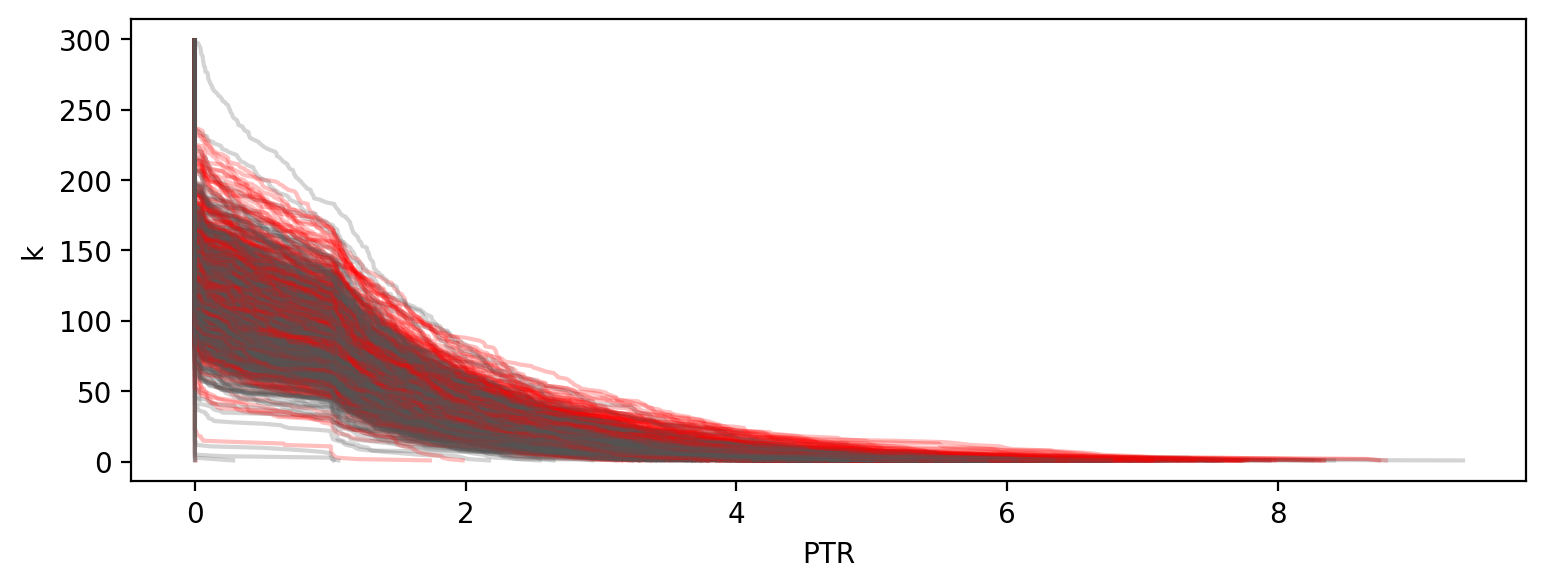

In [279]:

plt.figure(figsize=(9, 3))

select_ks = np.arange(1, 300, 1)

for orf_name, row in sorted_ptrs_df.dropna().iterrows():

    color = 'red' if orf_name in spellman_orfs else '#555'
    ptrs = row[select_ks]
    plt.plot(ptrs, select_ks, c=color, alpha=0.25)

plt.xlabel("PTR")
plt.ylabel("k")


In [292]:
sorted_ptrs_df.dropna()

,0,1,2,3,4,5,6,7,8,9,...,790,791,792,793,794,795,796,797,798,799
orf_name,,,,,,,,,,,,,,,,,,,,,
YAL067C,5.446276,4.976313,4.455798,4.455539,4.356698,4.339842,4.089955,4.060170,4.019689,3.726287,...,0.000003,0.000003,0.000003,0.000003,0.000003,0.000003,0.000003,0.000003,0.000002,0.000002
YAL053W,7.147913,5.774165,4.589052,4.032891,3.908500,3.752363,3.667614,3.574832,3.557978,3.531699,...,0.000003,0.000003,0.000003,0.000003,0.000003,0.000002,0.000002,0.000002,0.000002,0.000001
YAL040C,5.566477,4.721566,4.422804,4.190960,4.164959,4.037635,4.023822,3.758475,3.539795,3.111636,...,0.000002,0.000002,0.000002,0.000002,0.000002,0.000002,0.000002,0.000002,0.000001,0.000001
YAL022C,7.013700,5.153268,5.079227,4.608524,4.558012,3.826598,3.534871,3.437983,3.383633,3.379189,...,0.000006,0.000006,0.000006,0.000006,0.000005,0.000005,0.000003,0.000003,0.000002,0.000002
YAR003W,5.683340,5.591077,5.306570,4.666849,4.078514,4.005530,3.535634,3.295461,3.220741,3.208017,...,0.000003,0.000003,0.000003,0.000003,0.000003,0.000002,0.000002,0.000002,0.000002,0.000002
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
YPR188C,6.672829,4.815317,4.630067,4.545579,3.853477,3.784619,3.695100,3.478965,3.369494,3.025807,...,0.000005,0.000005,0.000004,0.000004,0.000003,0.000003,0.000003,0.000002,0.000002,0.000002
YPR192W,4.256504,4.135497,3.993278,3.863138,3.662056,3.549275,2.990389,2.687424,2.661538,2.635634,...,0.000005,0.000004,0.000004,0.000004,0.000004,0.000003,0.000003,0.000003,0.000002,0.000002
YPR199C,5.970685,5.841637,5.209350,4.807102,4.593369,4.211174,4.071877,3.750882,3.707735,3.662015,...,0.000003,0.000003,0.000003,0.000003,0.000002,0.000002,0.000002,0.000002,0.000002,0.000002


In [321]:
sorted_ptrs_df.dropna()

,0,1,2,3,4,5,6,7,8,9,...,790,791,792,793,794,795,796,797,798,799
orf_name,,,,,,,,,,,,,,,,,,,,,
YAL067C,5.446276,4.976313,4.455798,4.455539,4.356698,4.339842,4.089955,4.060170,4.019689,3.726287,...,0.000003,0.000003,0.000003,0.000003,0.000003,0.000003,0.000003,0.000003,0.000002,0.000002
YAL053W,7.147913,5.774165,4.589052,4.032891,3.908500,3.752363,3.667614,3.574832,3.557978,3.531699,...,0.000003,0.000003,0.000003,0.000003,0.000003,0.000002,0.000002,0.000002,0.000002,0.000001
YAL040C,5.566477,4.721566,4.422804,4.190960,4.164959,4.037635,4.023822,3.758475,3.539795,3.111636,...,0.000002,0.000002,0.000002,0.000002,0.000002,0.000002,0.000002,0.000002,0.000001,0.000001
YAL022C,7.013700,5.153268,5.079227,4.608524,4.558012,3.826598,3.534871,3.437983,3.383633,3.379189,...,0.000006,0.000006,0.000006,0.000006,0.000005,0.000005,0.000003,0.000003,0.000002,0.000002
YAR003W,5.683340,5.591077,5.306570,4.666849,4.078514,4.005530,3.535634,3.295461,3.220741,3.208017,...,0.000003,0.000003,0.000003,0.000003,0.000003,0.000002,0.000002,0.000002,0.000002,0.000002
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
YPR188C,6.672829,4.815317,4.630067,4.545579,3.853477,3.784619,3.695100,3.478965,3.369494,3.025807,...,0.000005,0.000005,0.000004,0.000004,0.000003,0.000003,0.000003,0.000002,0.000002,0.000002
YPR192W,4.256504,4.135497,3.993278,3.863138,3.662056,3.549275,2.990389,2.687424,2.661538,2.635634,...,0.000005,0.000004,0.000004,0.000004,0.000004,0.000003,0.000003,0.000003,0.000002,0.000002
YPR199C,5.970685,5.841637,5.209350,4.807102,4.593369,4.211174,4.071877,3.750882,3.707735,3.662015,...,0.000003,0.000003,0.000003,0.000003,0.000002,0.000002,0.000002,0.000002,0.000002,0.000002


In [461]:
sorted_ptrs_ranks_df = sorted_ptrs_df.dropna().copy()

ptr_ranks = ranks = np.argsort(np.argsort(sorted_ptrs_ranks_df.values, axis=0), axis=0) + 1

sorted_ptrs_ranks_df.loc[:] = ptr_ranks
sorted_ptrs_ranks_df = len(sorted_ptrs_ranks_df) - sorted_ptrs_ranks_df.astype(int)
sorted_ptrs_ranks_df

,0,1,2,3,4,5,6,7,8,9,...,790,791,792,793,794,795,796,797,798,799
orf_name,,,,,,,,,,,,,,,,,,,,,
YAL067C,898,768,826,595,494,334,409,301,238,350,...,961,858,739,684,506,423,292,320,211,228
YAL053W,224,320,739,945,865,855,773,741,617,542,...,919,916,902,764,737,865,895,915,1271,1182
YAL040C,833,936,856,808,635,569,450,551,645,974,...,1392,1389,1387,1381,1382,1377,1381,1362,1322,1225
YAL022C,256,656,411,490,349,769,911,881,814,694,...,95,76,45,27,31,28,122,342,231,803
YAR003W,769,398,287,457,710,595,908,1001,977,872,...,975,893,925,816,663,884,756,644,1095,961
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
YPR188C,359,880,702,525,915,816,748,838,829,1051,...,167,131,252,300,542,744,615,551,657,418
YPR192W,1328,1257,1164,1085,1078,1033,1284,1333,1315,1287,...,339,337,261,174,187,147,86,263,221,230
YPR199C,617,293,332,353,330,442,426,561,475,415,...,875,726,707,866,1103,1037,894,810,1153,874


In [462]:
# Compute the rank of the standard deviations of selected k values
rank_stds_df = sorted_ptrs_ranks_df.copy()
rank_stds_df.loc[:] = np.nan
for k in range(1, 800, 1):
    rank_stds_df.loc[:, k] = sorted_ptrs_ranks_df.loc[:, 0:k].std(axis=1)

rank_stds_df

,0,1,2,3,4,5,6,7,8,9,...,790,791,792,793,794,795,796,797,798,799
orf_name,,,,,,,,,,,,,,,,,,,,,
YAL067C,NaN,91.923882,65.125520,129.275868,167.222008,216.140464,217.717488,230.581524,243.671398,237.489204,...,132.183709,134.059073,135.254579,136.182092,136.480524,136.588408,136.527699,136.489634,136.404331,136.319378
YAL053W,NaN,67.882251,273.861887,341.919094,326.579699,307.632248,284.172399,264.143224,248.053478,237.643734,...,159.123979,159.168265,159.191674,159.097175,158.997487,158.974438,158.987808,159.029101,160.094431,160.801814
YAL040C,NaN,72.831998,54.064776,55.415852,110.775900,140.671840,177.141859,175.373683,165.251660,178.564679,...,296.013516,296.755041,297.484940,298.192359,298.896825,299.582063,300.272641,300.907255,301.436023,301.744551
YAL022C,NaN,282.842712,201.680440,166.483983,151.529865,193.008549,237.790824,249.512632,245.012131,232.339048,...,176.719611,178.513873,180.442939,182.437497,184.379147,186.306349,187.747014,188.336015,189.298594,189.180107
YAR003W,NaN,262.336616,252.416983,206.561331,206.854297,187.260247,221.339429,251.387542,260.515355,253.161872,...,142.819272,142.734122,142.663294,142.581475,142.661000,142.574071,142.530933,142.643897,142.800188,142.756701
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
YPR188C,NaN,368.402633,264.818806,224.663452,235.956988,218.627308,200.418610,191.293669,182.402028,198.948374,...,189.185134,191.626492,193.381093,194.884066,195.457610,195.555568,195.922476,196.459055,196.721086,197.687947
YPR192W,NaN,50.204581,82.245567,106.246569,108.960084,114.969126,115.329755,120.410904,119.498024,115.362424,...,208.055894,210.776274,213.900882,217.514263,220.967284,224.604431,228.562994,231.356871,234.340725,237.221188
YPR199C,NaN,229.102597,176.881316,147.608435,131.478135,119.877855,110.078760,116.905029,110.922395,104.630779,...,196.828379,196.996869,197.128522,197.626257,198.959945,200.010982,200.569550,200.901050,202.407911,202.893075


In [611]:
import numpy as np

def find_elbow_with_gradients(k, r):
    """Find the approximate elbow in the curve"""

    # Find the second derivatives of the input data
    first_derivative = np.diff(r) / np.diff(k)
    second_derivative = np.diff(first_derivative)
    
    # Ensure that we are only looking at negative gradients
    # when finding the elbow
    negative_second_derivative_indices = np.where(second_derivative < 0)[0]

    elbow_index = negative_second_derivative_indices[0]
    return k[elbow_index], r[elbow_index]


6


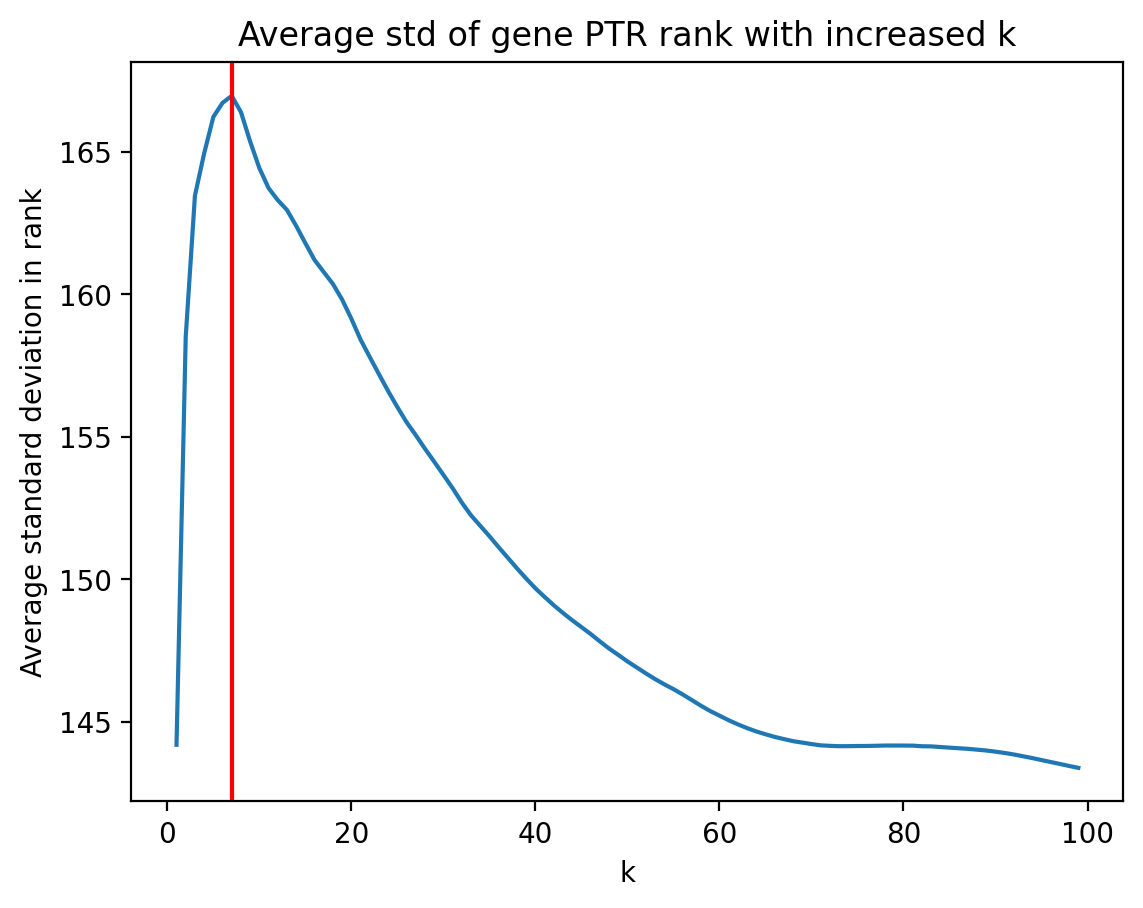

In [612]:
rank_mean_dat = rank_stds_df.mean(axis=0)[1:100]

plt.plot(rank_mean_dat.index, rank_mean_dat.values)

maximal_mean = rank_mean_dat.argmax()

plt.axvline(maximal_mean+1, c='red')
plt.xlabel("k")
plt.ylabel("Average standard deviation in rank")
plt.title("Average std of gene PTR rank with increased k")

print(maximal_mean)

# As the k increases from 0, the standard deviation of the rank increases,
# the rank has not stabilized and there is a lot of shuffling around
# At 6, the rank values have reached it maximum amount of change
# following 6, the rank values diminish, as we are introducing more stabilizing (but more
# noise introducing values into the ptr rank)

In [593]:

sorted_ptrs_6 = sorted_ptrs_ranks_df[[maximal_mean]].sort_values(maximal_mean).join(geneset[['gene']], how='inner')
sorted_ptrs_6['spellman'] = False

spellman_orfs_6 = list(set(spellman_orfs).intersection(set(sorted_ptrs_6.index.values)))
sorted_ptrs_6.loc[spellman_orfs_6, 'spellman'] = True

sorted_ptrs_6 = sorted_ptrs_6.join(sorted_ptrs_df[[maximal_mean]], lsuffix='rank', rsuffix='ptr')

Text(0, 0.5, 'Proportion of spellman genes')

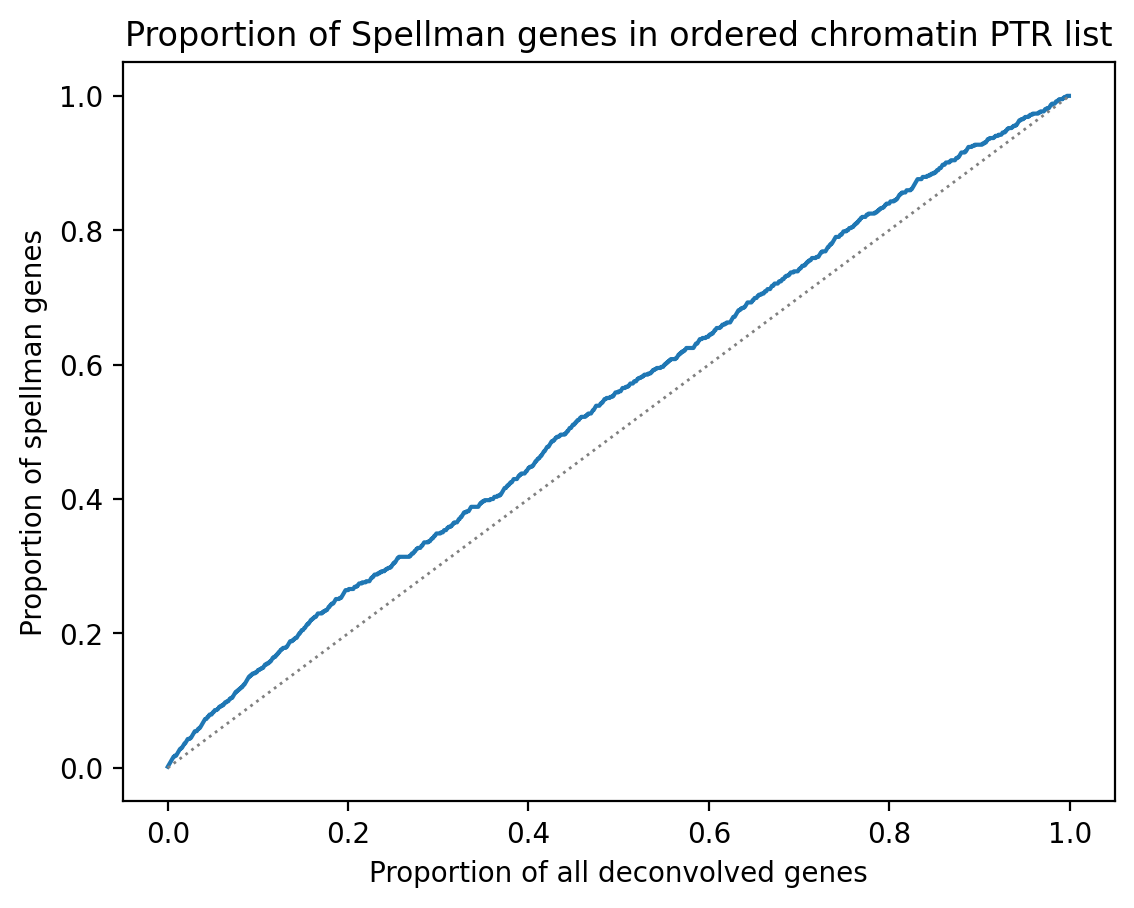

In [594]:
num_scs = len(spellman_orfs_6)
n = len(spellman_cumsum)

spellman_cumsum = sorted_ptrs_6.spellman.cumsum()
plt.plot(np.arange(n)/n, spellman_cumsum/num_scs)
plt.plot([0, 1], [0, 1], c='gray', ls='dotted', lw=1)
plt.title("Proportion of Spellman genes in ordered chromatin PTR list")
plt.xlabel("Proportion of all deconvolved genes")
plt.ylabel("Proportion of spellman genes")

In [595]:
sorted_ptrs_6.head(10)

,6rank,gene,spellman,6ptr
orf_name,,,,
YMR001C,0,CDC5,True,6.630615
YOR058C,1,ASE1,True,6.552431
YPL141C,2,FRK1,True,6.462780
YPR159W,3,KRE6,True,6.195513
YNL145W,4,MFA2,True,6.017698
YPR149W,5,NCE102,True,5.863074
YHL040C,6,ARN1,True,5.718796
YDR033W,7,MRH1,True,5.704858
YJL159W,8,HSP150,True,5.680984


In [596]:
sorted_ptrs_6.tail(10)

,6rank,gene,spellman,6ptr
orf_name,,,,
YOR084W,1390,LPX1,True,1.682728
YOL156W,1391,HXT11,False,1.541201
YDL039C,1392,PRM7,True,1.010926
YOR391C,1393,HSP33,False,1.003019
YLR461W,1394,PAU4,False,0.000417
YKR105C,1395,VBA5,False,0.000016
YFL060C,1396,SNO3,True,0.000014
YLL064C,1397,PAU18,False,0.000010
YLR466W,1398,YRF1-4,False,0.000010


q=0.95: 4.828
q=0.05: 2.823


Text(0.5, 1.0, 'Gene Peak-to-trough values')

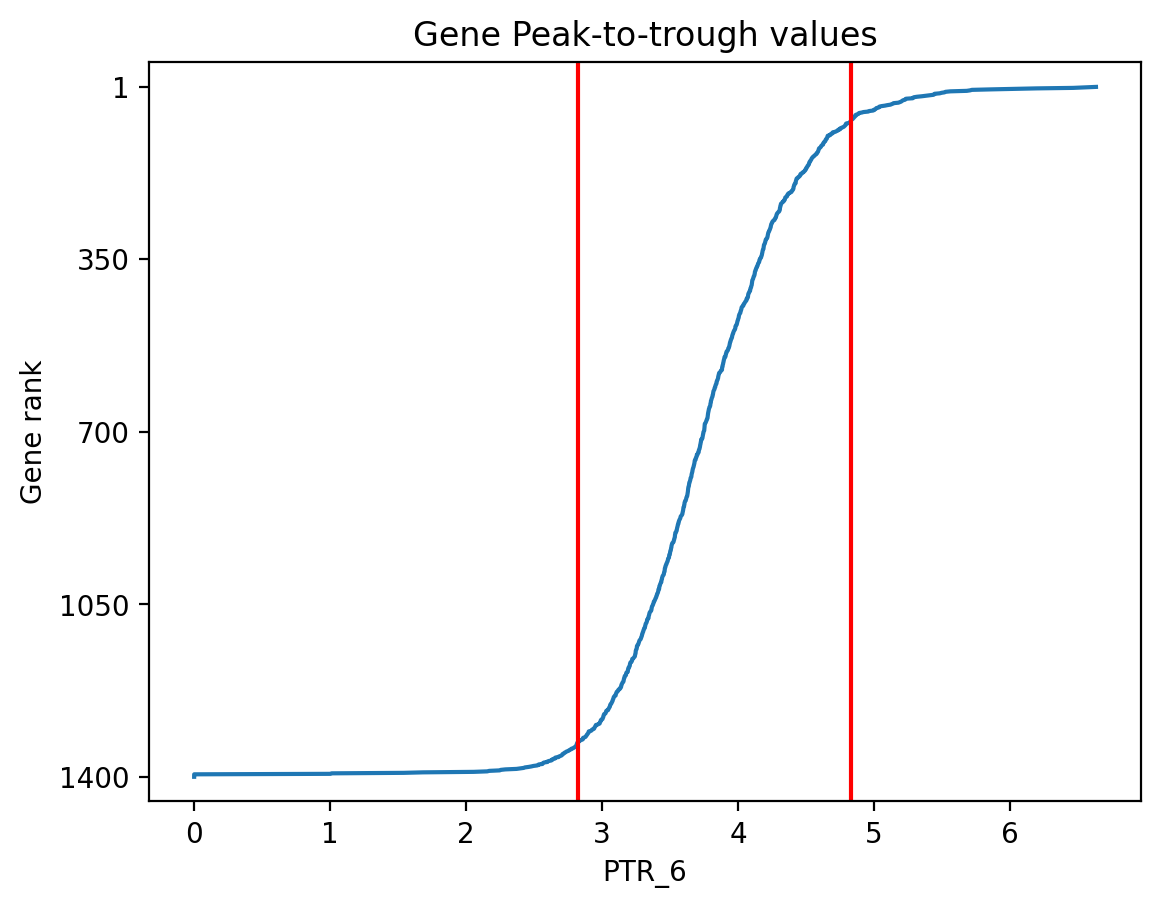

In [598]:
plt.plot(sorted_ptrs_6['6ptr'], sorted_ptrs_6['6rank']+1)
plt.xlabel('PTR_6')
plt.ylabel('Gene rank')
plt.yticks([1, n//4, n//2, 3*n//4, n])
plt.ylim(len(sorted_ptrs_6)+50, 1-50)

q95 = np.quantile(sorted_ptrs_6['6ptr'], q=0.95)
q05 = np.quantile(sorted_ptrs_6['6ptr'], q=0.05)

plt.axvline(q95, c='red')
plt.axvline(q05, c='red')

print(f"q=0.95: {q95:.3f}")
print(f"q=0.05: {q05:.3f}")
plt.title("Gene Peak-to-trough values")


Text(0, 0.5, 'Proportion of spellman genes')

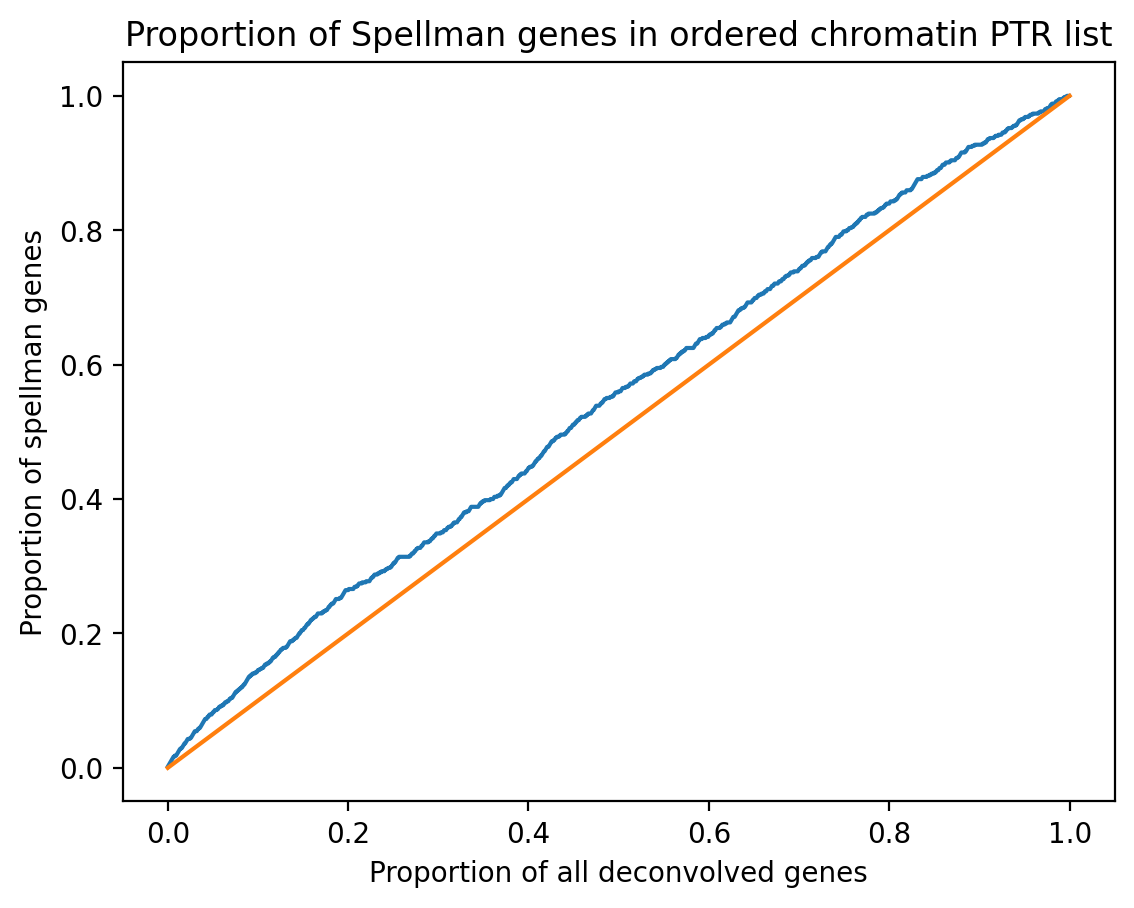

In [599]:
num_scs = len(spellman_orfs_6)
n = len(spellman_cumsum)

spellman_cumsum = sorted_ptrs_6.spellman.cumsum()
plt.plot(np.arange(n)/n, spellman_cumsum/num_scs)
plt.plot([0, 1], [0, 1])
plt.title("Proportion of Spellman genes in ordered chromatin PTR list")
plt.xlabel("Proportion of all deconvolved genes")
plt.ylabel("Proportion of spellman genes")

In [600]:
sorted_ptrs_6_spellman = sorted_ptrs_6[sorted_ptrs_6.spellman]

In [601]:
sorted_ptrs_6_spellman

,6rank,gene,spellman,6ptr
orf_name,,,,
YMR001C,0,CDC5,True,6.630615
YOR058C,1,ASE1,True,6.552431
YPL141C,2,FRK1,True,6.462780
YPR159W,3,KRE6,True,6.195513
YNL145W,4,MFA2,True,6.017698
...,...,...,...,...
YNL102W,1382,POL1,True,2.393478
YBL064C,1384,PRX1,True,2.288457
YOR084W,1390,LPX1,True,1.682728


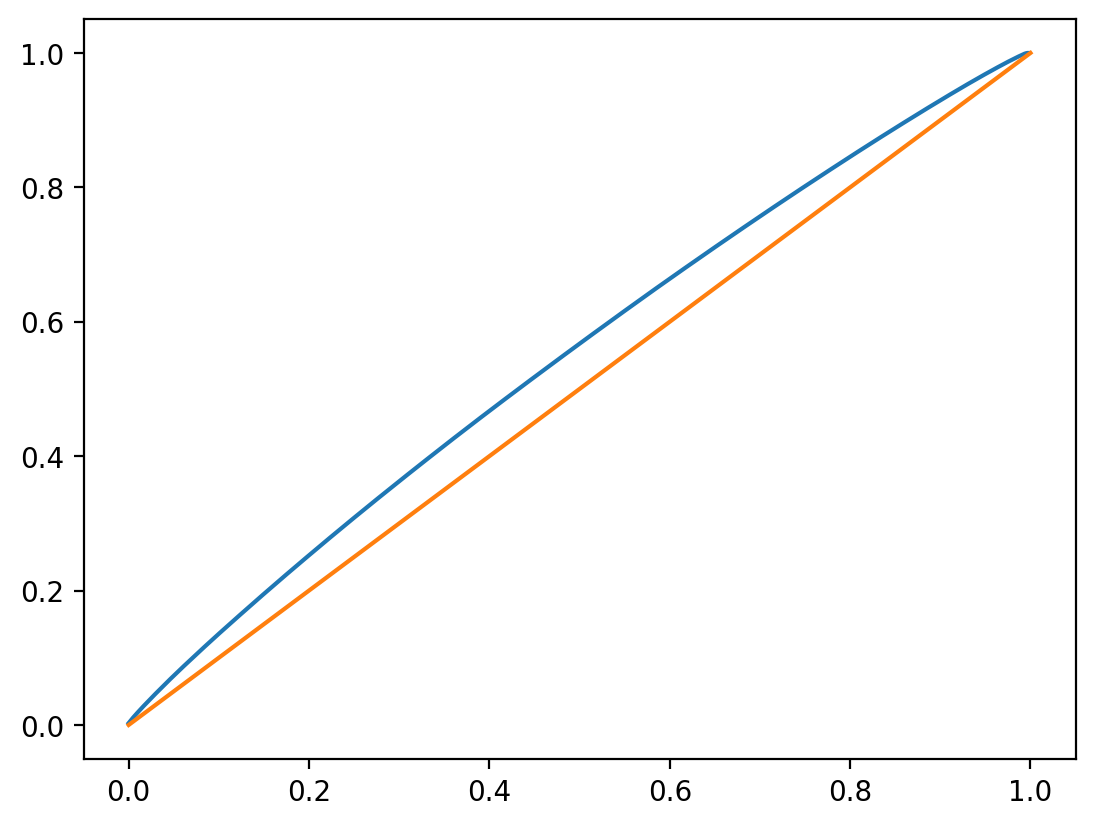

In [602]:
spellman6_cumsum_ptrs = sorted_ptrs_6_spellman['6ptr'].cumsum()
j = len(spellman6_cumsum_ptrs)

total_cumsum = sorted_ptrs_6_spellman['6ptr'].sum()

plt.plot(np.arange(len(spellman6_cumsum_ptrs))/j, 
   spellman6_cumsum_ptrs/total_cumsum)
plt.plot([0, 1], [0, 1])

In [603]:
sorted_ptrs_6_spellman

,6rank,gene,spellman,6ptr
orf_name,,,,
YMR001C,0,CDC5,True,6.630615
YOR058C,1,ASE1,True,6.552431
YPL141C,2,FRK1,True,6.462780
YPR159W,3,KRE6,True,6.195513
YNL145W,4,MFA2,True,6.017698
...,...,...,...,...
YNL102W,1382,POL1,True,2.393478
YBL064C,1384,PRX1,True,2.288457
YOR084W,1390,LPX1,True,1.682728
